In [32]:
import os

import anndata
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from Bio import Phylo
import scgenome.plotting as pl

from cellmates.common_helpers.cnasim_data import profiles_to_anndata


# CNAsim benchmark data visualization
Visualize CNAsim datasets replicated simulations with ancestral CN profiles and readcounts with same params as in the DICE paper published data: [zenodo link](https://zenodo.org/records/10108731)

## Defaults parameters
Each dataset shows variations of one or more parameters, all the rest are fixed to defaults parameters. Below is the list of parameters defaults:
```
defaults:
  n_cells: 250
  n_chromosomes: 22
  chromosome_length: 100
  mean_cnas_per_edge: 2
  bin_size: 1000000
  n_clones: 0
  wgd: false
  boundary_noise: 0
  jitter: 0
```

In [14]:
dat_path = "/home/vittorio.zampinetti/Cellmates/reproducibility/workflows/cnasim_makedata/results"

## A datasets

| Dataset | Number of cells |
|---------|-----------------|
| A1      | 10              |
| A2      | 25              |
| A3      | 50              |
| A4      | 75              |
| A5      | 100             |
| A6      | 250             |
| A7      | 500             |

In [15]:
test_dat = os.path.join(dat_path, "A3_0", "0")
tree_nwk_path = os.path.join(test_dat, "tree.nwk")
test_tree_bio = Phylo.read(tree_nwk_path,'newick')
test_adata = anndata.read_h5ad(os.path.join(test_dat, "anndata.h5ad"))
test_adata

AnnData object with n_obs × n_vars = 50 × 2879
    obs: 'normal', 'clone'
    var: 'chr', 'start', 'end'
    uns: 'ancestral-cn', 'ancestral-cnA', 'ancestral-cnB', 'ancestral-names', 'cell-tree-newick', 'clonal-tree-newick', 'clone-id-tree-newick', 'cnasim-params'
    layers: 'Acount', 'Astate', 'Bcount', 'Bstate', 'state'

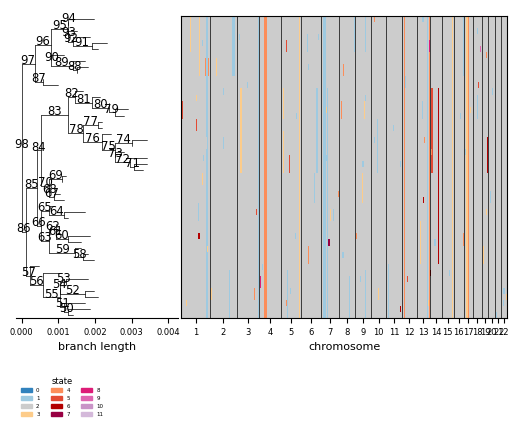

In [16]:
from io import StringIO
from cellmates.utils.tree_utils import make_gt_tree_dist

# use tree from cn-derived branch lengths
dpy_tree, gt_ctr = make_gt_tree_dist(test_adata, n_states=7, cell_names=test_adata.obs_names)
# rename dpy tree cells
for leaf in dpy_tree.leaf_node_iter():
    leaf.taxon.label = test_adata.obs_names[int(leaf.taxon.label)]
bio_tree_cn_lengths = Phylo.read(StringIO(dpy_tree.as_string(schema='newick')), 'newick', )
g = pl.plot_cell_cn_matrix_fig(test_adata, layer_name='state', tree=bio_tree_cn_lengths)

### Readcounts and ancestral cn sequences
Readcounts are probably too high in coverage and for Cellmates experiments a realistic parameter for that has to be found.

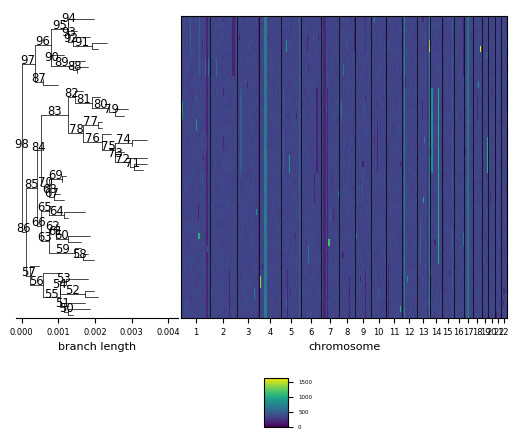

In [17]:
g = pl.plot_cell_cn_matrix_fig(test_adata, layer_name=None, tree=bio_tree_cn_lengths, raw=True)

In [18]:
test_adata.uns['ancestral-cn'].shape

(49, 2879)

In [19]:
test_adata.uns['ancestral-names'].shape # reference to tree names

(49,)

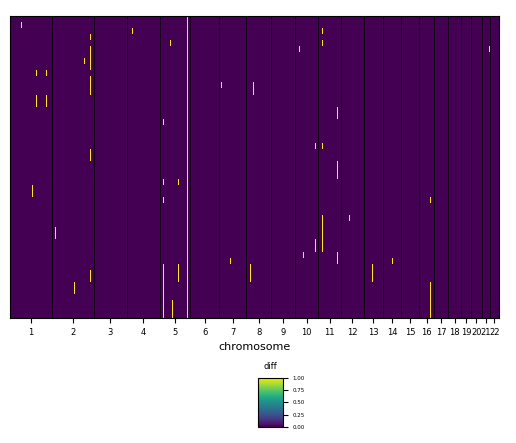

In [24]:
# breakpoint checks
test_adata.layers['diff'] = np.diff(test_adata.layers['state'], append=0) > 0
g = pl.plot_cell_cn_matrix_fig(test_adata, layer_name='diff', raw=True)

In [26]:
test_adata.layers['diff'].sum(axis=1)

array([24, 28, 23, 29, 28, 36, 30, 32, 33, 26, 35, 34, 31, 33, 29, 27, 33,
       31, 29, 28, 25, 34, 37, 36, 28, 35, 37, 35, 36, 36, 40, 28, 28, 35,
       29, 36, 37, 35, 31, 35, 33, 38, 43, 42, 48, 45, 43, 47, 48, 47])